# 05. Neural Network Development (MLP)

## 1. Tổng quan (Overview)
Trong notebook này, nhóm sẽ triển khai mô hình **Multi-Layer Perceptron (MLP)** - một dạng mạng Nơ-ron nhân tạo sâu (Deep Learning) để giải quyết bài toán dự đoán trầm cảm. 

**Tại sao sử dụng Neural Network cho dữ liệu bảng?**
Mặc dù các mô hình Boosting thường chiếm ưu thế trên dữ liệu bảng, Neural Network với kiến trúc MLP lại có khả năng học được các tương tác phi tuyến tính (non-linear interactions) cực kỳ phức tạp giữa các đặc trưng mà các mô hình truyền thống có thể bỏ sót.

**Chiến lược thực hiện:**
- Sử dụng framework **PyTorch**.
- Tận dụng bộ dữ liệu đã được **Chuẩn hóa (Scaled)** và **Nội suy (Imputed)** từ bước tiền xử lý để đảm bảo tốc độ hội tụ của thuật toán Gradient Descent.
- Thiết lập luồng dữ liệu chuẩn thông qua PyTorch `Dataset` và `DataLoader`.

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (roc_curve, roc_auc_score, f1_score, accuracy_score, 
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

# Cấu hình đường dẫn
INPUT_DIR = '../outputs'
OUTPUT_DIR = '../outputs/artifacts'

os.makedirs(OUTPUT_DIR, exist_ok=True)
# 1. Load Meta Information để đồng bộ hóa tham số
with open(f"{INPUT_DIR}/meta_info.pkl", "rb") as f:
    meta = pickle.load(f)

RANDOM_STATE = meta['random_seed']
N_FOLDS = meta['n_folds']
# Trọng số để xử lý mất cân bằng lớp (Dùng cho Weighted BCE Loss)
POS_WEIGHT = torch.tensor([meta['scale_pos_weight']]) 

print(f"Cấu hình đã nạp: Seed={RANDOM_STATE}, Folds={N_FOLDS}")
print(f"Trọng số lớp dương (Positive Weight): {POS_WEIGHT.item():.4f}")

# Thiết lập thiết bị tính toán (GPU nếu có, không thì dùng CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang sử dụng: {device}")

Cấu hình đã nạp: Seed=42, Folds=5
Trọng số lớp dương (Positive Weight): 4.5032
Thiết bị đang sử dụng: cpu


## 2. Chuẩn bị Dữ liệu (Data Preparation)

Chúng ta sẽ sử dụng bộ dữ liệu `train_nn_ready.pkl` - đây là biến thể dữ liệu đã được xử lý bằng **RobustScaler** và **MICE Imputer**, vốn là môi trường lý tưởng cho các hàm kích hoạt (Activation Functions) của mạng Nơ-ron hoạt động hiệu quả.

**Lưu ý quan trọng:** Chúng ta sẽ loại bỏ cột `KFOLD` nếu nó tồn tại để tránh rò rỉ dữ liệu (Data Leakage), vì đây chỉ là biến phục vụ chia nếp gấp, không phải là đặc trưng học máy.

In [2]:
# 1. Tải dữ liệu đặc trưng và nhãn
X_all = pd.read_pickle(f"{INPUT_DIR}/train_nn_ready.pkl")
y_all = pd.read_pickle(f"{INPUT_DIR}/y_train.pkl")

# 2. Loại bỏ cột metadata KFOLD nếu có
if 'KFOLD' in X_all.columns:
    X_all = X_all.drop(columns=['KFOLD'])
    print("Đã loại bỏ cột KFOLD khỏi dữ liệu huấn luyện.")

# 3. Phân tách tập Train (80%) và Validation (20%)
# Sử dụng stratify=y_all để giữ nguyên tỷ lệ lớp nhãn
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, 
    test_size=0.20, 
    stratify=y_all, 
    random_state=RANDOM_STATE
)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Validation: {X_val.shape}")

Đã loại bỏ cột KFOLD khỏi dữ liệu huấn luyện.
Kích thước tập Train: (112560, 32)
Kích thước tập Validation: (28140, 32)


## 3. Khởi tạo PyTorch Dataset

Mạng Nơ-ron trong PyTorch không thể đọc trực tiếp định dạng Pandas DataFrame. Chúng ta cần đóng gói dữ liệu vào một lớp `Dataset` tùy chỉnh để chuyển đổi các đặc trưng và nhãn sang dạng **Tensors (Float32)**. Việc này cũng giúp tối ưu hóa bộ nhớ khi huấn luyện theo từng lô (Batch Training).

In [3]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        # Chuyển đổi dữ liệu sang Tensor Float32
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Khởi tạo các đối tượng Dataset cho Train và Val
train_dataset = TabularDataset(X_train, y_train)
val_dataset = TabularDataset(X_val, y_val)

print("Đã khởi tạo thành công luồng dữ liệu PyTorch Dataset.")

Đã khởi tạo thành công luồng dữ liệu PyTorch Dataset.


## 4. Xây dựng Kiến trúc Mạng Nơ-ron (MLP Architecture)

Chúng ta sẽ thiết kế một mạng **Multi-Layer Perceptron (MLP)** với 3 lớp ẩn (Hidden Layers). Kiến trúc này được tối ưu hóa để xử lý dữ liệu bảng thông qua các kỹ thuật bổ trợ:

- **Batch Normalization (BN):** Giúp chuẩn hóa đầu ra của các lớp ẩn, tăng tốc độ hội tụ và giảm độ nhạy với việc khởi tạo trọng số.
- **Hàm kích hoạt ReLU:** Giúp mô hình học được các đặc trưng phi tuyến tính phức tạp.
- **Dropout (p=0.3):** Một kỹ thuật Regularization giúp ngăn chặn hiện tượng Overfitting bằng cách ngắt ngẫu nhiên 30% kết nối trong quá trình huấn luyện.
- **Hàm Sigmoid ở lớp cuối:** Chuyển đổi đầu ra thành xác suất (0 đến 1) cho bài toán phân loại nhị phân.

In [4]:
class DepressionMLP(nn.Module):
    def __init__(self, input_dim):
        super(DepressionMLP, self).__init__()
        
        # 1. Lớp đầu vào và Batch Normalization đầu tiên
        self.bn_input = nn.BatchNorm1d(input_dim)
        
        # 2. Lớp ẩn thứ nhất: input_dim -> 256
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        
        # 3. Lớp ẩn thứ hai: 256 -> 128
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        
        # 4. Lớp ẩn thứ ba: 128 -> 64
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        
        # 5. Lớp đầu ra (Output): 64 -> 1
        self.fc_out = nn.Linear(64, 1)
        
        # Các thành phần bổ trợ
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Input -> BN
        x = self.bn_input(x)
        
        # Lớp 1: Dense(256) -> BN -> ReLU -> Dropout
        x = self.dropout(self.relu(self.bn1(self.fc1(x))))
        
        # Lớp 2: Dense(128) -> BN -> ReLU -> Dropout
        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
        
        # Lớp 3: Dense(64) -> BN -> ReLU -> Dropout
        x = self.dropout(self.relu(self.bn3(self.fc3(x))))
        
        # Output layer: Logits (để dùng với BCEWithLogitsLoss)
        x = self.fc_out(x)
        
        return x

## 5. Khởi tạo và Kiểm tra Kiến trúc (Model Summary)

Chúng ta tiến hành khởi tạo mô hình dựa trên số lượng đặc trưng đầu vào (`input_dim`) đã chuẩn bị ở Phần 1 và chuyển mô hình vào thiết bị tính toán (CPU/GPU). Việc in cấu trúc mô hình giúp xác nhận các lớp đã được thiết lập đúng như thiết kế.

In [5]:
# Xác định số lượng đặc trưng đầu vào
input_dim = X_train.shape[1]

# Khởi tạo mô hình
model = DepressionMLP(input_dim).to(device)

# Hiển thị cấu trúc mô hình
print("--- KIẾN TRÚC MÔ HÌNH MLP ---")
print(model)
# Đưa mô hình về chế độ đánh giá để tắt Dropout và dùng Running Stats của BN
model.eval()
# Kiểm tra thử với một lô dữ liệu nhỏ (Dummy input)
dummy_input = torch.randn(2, input_dim).to(device)
with torch.no_grad():
    output = model(dummy_input)
    print(f"\nKích thước Tensor đầu ra: {output.shape}")
    print(f"Dữ liệu đầu ra thử nghiệm (Logits thô của 2 mẫu): \n{output.cpu().numpy()}")

model.train()

--- KIẾN TRÚC MÔ HÌNH MLP ---
DepressionMLP(
  (bn_input): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=32, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (sigmoid): Sigmoid()
)

Kích thước Tensor đầu ra: torch.Size([2, 1])
Dữ liệu đầu ra thử nghiệm (Logits thô của 2 mẫu): 
[[-0.09356168]
 [-0.0985595 ]]


DepressionMLP(
  (bn_input): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=32, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (sigmoid): Sigmoid()
)

**Nhận xét:** Kết quả **torch.Size([2, 1])** khẳng định rằng mô hình đã hiểu đúng yêu cầu: "Với mỗi người (trong 2 người thử nghiệm), hãy trả về 1 con số dự đoán duy nhất".

## 6. Cấu hình Huấn luyện & Cơ chế Dừng sớm (Early Stopping)

Để đảm bảo mô hình hội tụ tốt nhất mà không bị Overfitting, chúng ta bám sát cấu hình sau:
- **Optimizer:** `AdamW` (Adam với Weight Decay) giúp phạt các trọng số quá lớn (`weight_decay=1e-4`), tỷ lệ học `lr=1e-3`.
- **Scheduler:** `CosineAnnealingLR` giúp giảm dần learning rate theo hình chuông, giúp mô hình "hạ cánh" mượt mà vào điểm cực tiểu của hàm Loss.
- **Loss Function:** `BCEWithLogitsLoss` kết hợp `pos_weight` để phạt nặng hơn nếu mô hình đoán sai lớp thiểu số (Depression).
- **Early Stopping:** Theo dõi Validation Loss. Nếu sau 15 epochs (`patience=15`) mà loss không giảm, tiến trình sẽ tự động dừng và khôi phục lại bộ trọng số (weights) tốt nhất.

In [6]:
class EarlyStopping:
    """
    Theo dõi Validation Loss, nếu không giảm sau 'patience' epochs thì dừng sớm.
    Đồng thời tự động lưu lại model có Val Loss thấp nhất.
    """
    def __init__(self, patience=15, delta=0.0, path=f'{OUTPUT_DIR}/best_mlp_checkpoint.pt'):
        self.patience = patience
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        # Lần lặp đầu tiên
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        # Nếu loss bị tăng lên (tệ đi)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        # Nếu loss tiếp tục giảm (tốt lên)
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        """Lưu model khi validation loss giảm."""
        # Chỉ in ra khi test 1 fold, trong CV loop ta có thể ẩn đi cho đỡ rối
        # print(f"Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model ...")
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

## 7. Khởi tạo Hàm Train & Evaluate cho từng Epoch

Mạng Nơ-ron yêu cầu định nghĩa rõ ràng vòng lặp Forward Pass và Backward Pass. Chúng ta sẽ viết 2 hàm trợ trợ:
- `train_epoch`: Đẩy dữ liệu qua model, tính Loss, và cập nhật trọng số (Backward step).
- `eval_epoch`: Đóng băng trọng số (`torch.no_grad()`), tính toán Validation Loss và Validation AUC-ROC.

In [7]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train() # Bật chế độ train (kích hoạt Dropout & BatchNorm)
    total_loss = 0.0
    
    for batch_X, batch_y in dataloader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # Xóa gradient cũ
        optimizer.zero_grad()
        
        # Forward pass (Dự đoán)
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        # Backward pass (Tính đạo hàm & cập nhật trọng số)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch_X.size(0)
        
    return total_loss / len(dataloader.dataset)

def eval_epoch(model, dataloader, criterion, device):
    model.eval() # Bật chế độ đánh giá (tắt Dropout, đóng băng BatchNorm)
    total_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            total_loss += loss.item() * batch_X.size(0)
            
            # Chuyển logit thành xác suất bằng sigmoid để tính AUC
            probs = torch.sigmoid(predictions).cpu().numpy()
            all_preds.extend(probs)
            all_targets.extend(batch_y.cpu().numpy())
            
    avg_loss = total_loss / len(dataloader.dataset)
    auc_score = roc_auc_score(all_targets, all_preds)
    
    return avg_loss, auc_score

## 8. Huấn luyện với 5-Fold Stratified Cross-Validation

Để có cái nhìn khách quan về hiệu năng của Mạng Nơ-ron, chúng ta sẽ thực hiện đánh giá chéo 5 nếp gấp (5-Fold CV) trên tập Huấn luyện (80%). 

**Quy trình thực hiện trong mỗi nếp gấp (Fold):**
1. Chia tập Train thành 2 phần: **Sub-train** để học và **Hold-out fold** để kiểm chứng.
2. Khởi tạo mới hoàn toàn trọng số mô hình, bộ tối ưu hóa và bộ lập lịch.
3. Chạy vòng lặp huấn luyện tối đa 150 Epochs, kết hợp với **Early Stopping** để dừng lại ngay khi mô hình có dấu hiệu Overfitting (sau 15 epochs không cải thiện).
4. Lưu lại xác suất dự đoán của từng Fold để tạo mảng **OOF Predictions**.
5. Tính toán **Mean AUC** và **Std AUC** để đo lường độ ổn định của kiến trúc MLP.

In [8]:
# 1. Khởi tạo các biến lưu trữ kết quả CV
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_probs = np.zeros(len(X_train))
cv_auc_scores = []

# Để indexing X_train, y_train dễ dàng hơn bằng iloc
X_tr_reset = X_train.reset_index(drop=True)
y_tr_reset = y_train.reset_index(drop=True)

print(f"Bắt đầu quy trình {N_FOLDS}-Fold CV cho Neural Network...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_tr_reset, y_tr_reset), 1):
    print(f"\n--- [FOLD {fold}/{N_FOLDS}] ---")
    
    # Chia dữ liệu cho từng Fold
    x_train_fold, x_val_fold = X_tr_reset.iloc[train_idx], X_tr_reset.iloc[val_idx]
    y_train_fold, y_val_fold = y_tr_reset.iloc[train_idx], y_tr_reset.iloc[val_idx]
    
    # Khởi tạo Dataloaders
    train_fold_ds = TabularDataset(x_train_fold, y_train_fold)
    val_fold_ds = TabularDataset(x_val_fold, y_val_fold)
    
    train_loader = DataLoader(train_fold_ds, batch_size=256, shuffle=True)
    val_loader = DataLoader(val_fold_ds, batch_size=256, shuffle=False)
    
    # Khởi tạo Model, Criterion, Optimizer, Scheduler và EarlyStopping mới cho mỗi Fold
    model_fold = DepressionMLP(input_dim).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT.to(device))
    optimizer = optim.AdamW(model_fold.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150)
    
    checkpoint_path = f"{OUTPUT_DIR}/mlp_fold_{fold}.pt"
    early_stopping = EarlyStopping(patience=15, path=checkpoint_path)
    
    # Vòng lặp Epochs
    for epoch in range(1, 151):
        tr_loss = train_epoch(model_fold, train_loader, criterion, optimizer, device)
        va_loss, va_auc = eval_epoch(model_fold, val_loader, criterion, device)
        
        scheduler.step()
        early_stopping(va_loss, model_fold)
        
        is_best = (early_stopping.counter == 0)
        if epoch % 20 == 0 or epoch == 1 or is_best:
            marker = " <--- BEST FOUND!" if is_best and epoch > 1 else ""
            print(f"Epoch {epoch:03d}: Train Loss: {tr_loss:.4f} | Val Loss: {va_loss:.4f} | Val AUC: {va_auc:.4f}{marker}")
            
        if early_stopping.early_stop:
            print(f"\n--- [THÔNG BÁO] ---")
            print(f"Dừng sớm tại Epoch {epoch}.")
            print(f"Best Val Loss đã đạt được: {early_stopping.val_loss_min:.4f}")
            break
            
    # Load lại trọng số tốt nhất của Fold này để dự đoán OOF
    model_fold.load_state_dict(torch.load(checkpoint_path))
    model_fold.eval()
    
    fold_preds = []
    with torch.no_grad():
        for batch_X, _ in val_loader:
            batch_X = batch_X.to(device)
            outputs = model_fold(batch_X)
            probs = torch.sigmoid(outputs).cpu().numpy()
            fold_preds.extend(probs.flatten())
            
    oof_probs[val_idx] = fold_preds
    fold_final_auc = roc_auc_score(y_val_fold, fold_preds)
    cv_auc_scores.append(fold_final_auc)
    print(f"KẾT THÚC FOLD {fold} - AUC Đạt được: {fold_final_auc:.4f}")

# Tính toán kết quả CV tổng thể
print("\n" + "="*40)
print(f"KẾT QUẢ CV {N_FOLDS}-FOLD (TRÊN 80% TRAIN SET):")
print(f"Mean AUC: {np.mean(cv_auc_scores):.4f} (+/- {np.std(cv_auc_scores):.4f})")
print("="*40)

# Lưu OOF Probs để dùng cho Ensemble sau này
np.save(f"{OUTPUT_DIR}/nn_oof_probs.npy", oof_probs)

Bắt đầu quy trình 5-Fold CV cho Neural Network...

--- [FOLD 1/5] ---
Epoch 001: Train Loss: 0.4038 | Val Loss: 0.3358 | Val AUC: 0.9740
Epoch 002: Train Loss: 0.3533 | Val Loss: 0.3314 | Val AUC: 0.9747 <--- BEST FOUND!
EarlyStopping counter: 1 out of 15
EarlyStopping counter: 2 out of 15
Epoch 005: Train Loss: 0.3433 | Val Loss: 0.3310 | Val AUC: 0.9746 <--- BEST FOUND!
Epoch 006: Train Loss: 0.3395 | Val Loss: 0.3309 | Val AUC: 0.9748 <--- BEST FOUND!
EarlyStopping counter: 1 out of 15
Epoch 008: Train Loss: 0.3368 | Val Loss: 0.3298 | Val AUC: 0.9748 <--- BEST FOUND!
EarlyStopping counter: 1 out of 15
EarlyStopping counter: 2 out of 15
EarlyStopping counter: 3 out of 15
EarlyStopping counter: 4 out of 15
EarlyStopping counter: 5 out of 15
EarlyStopping counter: 6 out of 15
EarlyStopping counter: 7 out of 15
EarlyStopping counter: 8 out of 15
EarlyStopping counter: 9 out of 15
EarlyStopping counter: 10 out of 15
EarlyStopping counter: 11 out of 15
EarlyStopping counter: 12 out of 15

## 9. Đánh giá trên tập Validation (Hold-out 20%)

Sau khi xác nhận độ ổn định của cấu trúc mạng qua 5-Fold CV, chúng ta sẽ tiến hành **Refit (Huấn luyện lại)** mô hình trên toàn bộ tập Huấn luyện (80%). Việc này giúp mô hình học được nhiều pattern nhất có thể trước khi đối mặt với tập Kiểm chứng (20%).

Các tham số và cơ chế Early Stopping vẫn được giữ nguyên như quá trình Cross-Validation.

In [9]:
print("Bắt đầu Huấn luyện lại (Refit) trên toàn bộ 80% tập Train...")

# 1. Khởi tạo DataLoaders cho toàn bộ Train và Val
train_ds_full = TabularDataset(X_train, y_train)
val_ds_full = TabularDataset(X_val, y_val)

train_loader_full = DataLoader(train_ds_full, batch_size=256, shuffle=True)
val_loader_full = DataLoader(val_ds_full, batch_size=256, shuffle=False)

# 2. Khởi tạo lại Model và các thành phần tối ưu
final_model = DepressionMLP(input_dim).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT.to(device))
optimizer = optim.AdamW(final_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150)

checkpoint_final = f"{OUTPUT_DIR}/best_mlp_final.pt"
early_stopping_final = EarlyStopping(patience=15, path=checkpoint_final)


# 3. Vòng lặp Huấn luyện
for epoch in range(1, 151):
    tr_loss = train_epoch(final_model, train_loader_full, criterion, optimizer, device)
    va_loss, va_auc = eval_epoch(final_model, val_loader_full, criterion, device)
    
    scheduler.step()
    early_stopping_final(va_loss, final_model)
    
    is_best = (early_stopping_final.counter == 0)
    
    if epoch % 20 == 0 or epoch == 1 or is_best:
        marker = " <--- BEST FOUND!" if is_best and epoch > 1 else ""
        print(f"Epoch {epoch:03d}: Train Loss: {tr_loss:.4f} | Val Loss: {va_loss:.4f} | Val AUC: {va_auc:.4f}{marker}")
        
    if early_stopping_final.early_stop:
        print(f"\n--- [THÔNG BÁO] ---")
        print(f"Dừng sớm tại Epoch {epoch}.")
        print(f"Best Val Loss đã đạt được: {early_stopping_final.val_loss_min:.4f}")
        break

# 4. Tải trọng số tốt nhất và Dự đoán trên tập Validation
final_model.load_state_dict(torch.load(checkpoint_final))
final_model.eval()

val_probs_nn = []
with torch.no_grad():
    for batch_X, _ in val_loader_full:
        batch_X = batch_X.to(device)
        outputs = final_model(batch_X)
        probs = torch.sigmoid(outputs).cpu().numpy()
        val_probs_nn.extend(probs.flatten())

val_probs_nn = np.array(val_probs_nn)
print(f"Hoàn tất dự đoán trên tập Validation. Kích thước mảng dự đoán: {val_probs_nn.shape}")

Bắt đầu Huấn luyện lại (Refit) trên toàn bộ 80% tập Train...
Epoch 001: Train Loss: 0.3951 | Val Loss: 0.3394 | Val AUC: 0.9735
Epoch 002: Train Loss: 0.3468 | Val Loss: 0.3385 | Val AUC: 0.9735 <--- BEST FOUND!
EarlyStopping counter: 1 out of 15
Epoch 004: Train Loss: 0.3415 | Val Loss: 0.3375 | Val AUC: 0.9737 <--- BEST FOUND!
EarlyStopping counter: 1 out of 15
EarlyStopping counter: 2 out of 15
EarlyStopping counter: 3 out of 15
EarlyStopping counter: 4 out of 15
EarlyStopping counter: 5 out of 15
EarlyStopping counter: 6 out of 15
EarlyStopping counter: 7 out of 15
EarlyStopping counter: 8 out of 15
EarlyStopping counter: 9 out of 15
EarlyStopping counter: 10 out of 15
EarlyStopping counter: 11 out of 15
EarlyStopping counter: 12 out of 15
EarlyStopping counter: 13 out of 15
EarlyStopping counter: 14 out of 15
EarlyStopping counter: 15 out of 15

--- [THÔNG BÁO] ---
Dừng sớm tại Epoch 19.
Best Val Loss đã đạt được: 0.3375
Hoàn tất dự đoán trên tập Validation. Kích thước mảng dự đoá

## 10. Phân tích Tầm quan trọng của Đặc trưng (Feature Importance)
Mạng nơ-ron MLP thường bị coi là "Black-box" (hộp đen) vì các trọng số nằm chồng chéo trong các lớp ẩn. Để giải mã xem mô hình đang ưu tiên những yếu tố nào khi dự đoán trầm cảm, ta cần sử dụng kỹ thuật **Permutation Importance**.

Kỹ thuật này đánh giá tầm quan trọng của một biến bằng cách đo lường sự sụt giảm của hiệu năng mô hình (AUC) khi giá trị của biến đó bị xáo trộn ngẫu nhiên. Nếu một đặc trưng thực sự quan trọng, việc làm nhiễu nó sẽ khiến khả năng dự đoán của mô hình bị ảnh hưởng nghiêm trọng.

Bắt đầu tính toán Permutation Importance (quy trình này có thể mất vài phút)...
AUC gốc của mô hình: 0.9737
Đang tính toán Feature Importance cho 32 đặc trưng...


Đang tính Feature Importance:   0%|          | 0/32 [00:00<?, ?it/s]

Đã lưu biểu đồ đặc trưng quan trọng tại: ../outputs/artifacts/mlp_feature_importance.png


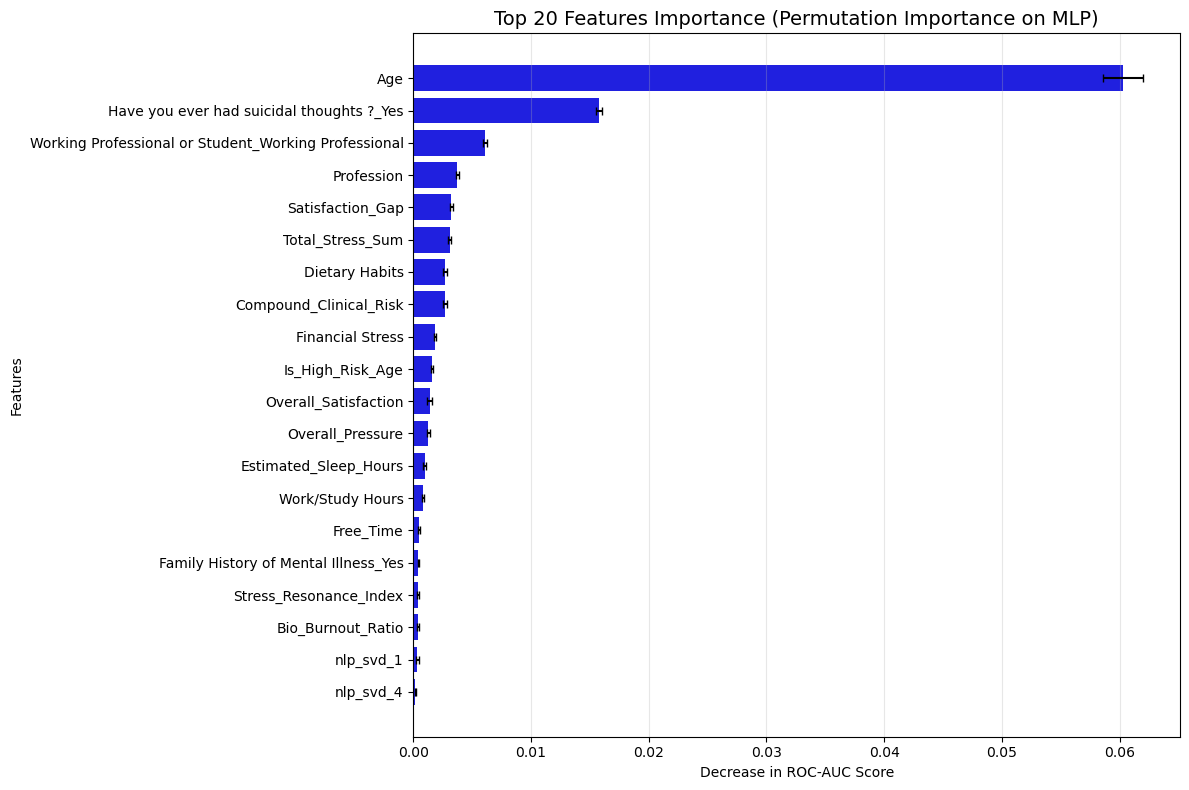


--- TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT ---
                                              feature  importance_mean
0                                                 Age         0.060318
30          Have you ever had suicidal thoughts ?_Yes         0.015774
29  Working Professional or Student_Working Profes...         0.006102
2                                          Profession         0.003715
17                                   Satisfaction_Gap         0.003233
10                                   Total_Stress_Sum         0.003094
4                                      Dietary Habits         0.002697
16                             Compound_Clinical_Risk         0.002680
7                                    Financial Stress         0.001850
15                                   Is_High_Risk_Age         0.001566


In [ ]:
# Tạo một hàm wrapper để Scikit-learn có thể giao tiếp với PyTorch model
def predict_proba_nn(X_numpy):
    final_model.eval()
    X_tensor = torch.tensor(X_numpy, dtype=torch.float32).to(device)
    with torch.no_grad():
        outputs = final_model(X_tensor)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
    return probs

print("Bắt đầu tính toán Permutation Importance (quy trình này có thể mất vài phút)...")

# Tính AUC gốc (Baseline)
baseline_auc = roc_auc_score(y_val, predict_proba_nn(X_val.values))
print(f"AUC gốc của mô hình: {baseline_auc:.4f}")

# Chuẩn bị biến lưu kết quả
feature_names = X_train.columns
importances = []
n_repeats = 5

print(f"Đang tính toán Feature Importance cho {len(feature_names)} đặc trưng...")

for col in tqdm(feature_names, desc="Đang tính Feature Importance"):
    col_scores = []
    
    for i in range(n_repeats):
        X_val_permuted = X_val.copy().values
        col_idx = list(feature_names).index(col)
        
        # Xáo trộn ngẫu nhiên duy nhất cột hiện tại
        X_val_permuted[:, col_idx] = np.random.permutation(X_val_permuted[:, col_idx])
     
        new_auc = roc_auc_score(y_val, predict_proba_nn(X_val_permuted))
        
        col_scores.append(baseline_auc - new_auc)
    
    importances.append({
        'feature': col,
        'importance_mean': np.mean(col_scores),
        'importance_std': np.std(col_scores)
    })

importance_df = pd.DataFrame(importances).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='importance_mean', 
    y='feature', 
    data=importance_df.head(20),
    color ='blue'
)
plt.errorbar(
    x=importance_df.head(20)['importance_mean'], 
    y=range(20), 
    xerr=importance_df.head(20)['importance_std'], 
    fmt='none', c='black', capsize=3
)

plt.title('Top 20 Features Importance (Permutation Importance on MLP)', fontsize=14)
plt.xlabel('Decrease in ROC-AUC Score')
plt.ylabel('Features')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_path = f"{OUTPUT_DIR}/mlp_feature_importance.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Đã lưu biểu đồ đặc trưng quan trọng tại: {save_path}")
plt.show()

**Nhận xét và Insight chuyên sâu:**
1. Nhận xét tổng quan về biểu đồ
- Đặc trưng quan trọng nhất: Age (Độ tuổi) là yếu tố áp đảo hoàn toàn. Khi xáo trộn cột này, điểm ROC-AUC của mô hình sụt giảm tới gần 0.06 (6%) — một con số cực lớn trong Machine Learning.

- Sự phân hóa: Có một khoảng cách khá xa giữa đặc trưng Top 1 (Age) và các đặc trưng còn lại. Điều này cho thấy Age là "xương sống" trong logic dự đoán của mô hình.

- Độ tin cậy: Các thanh sai số (error bars) ở đầu các cột khá ngắn, chứng tỏ kết quả này rất ổn định qua 5 lần xáo trộn (n_repeats=5).

2. Các Insight quan trọng
- Yếu tố nhân khẩu học là "kim chỉ nam": Việc Age đứng đầu cho thấy trầm cảm trong tập dữ liệu này có sự phân hóa rất rõ rệt theo lứa tuổi. Có thể các nhóm tuổi trẻ (sinh viên) hoặc nhóm tuổi lao động chịu những áp lực rất khác nhau, và mô hình đã nắm bắt được "mẫu hình" (pattern) này để phân loại.
- Dấu hiệu tâm lý trực tiếp: Việc `"Have you ever had suicidal thoughts?_Yes"` đứng vị trí thứ 2 là hoàn toàn hợp lý về mặt lâm sàng. Đây là một trong những chỉ báo mạnh nhất của tình trạng sức khỏe tâm thần nghiêm trọng. Việc mô hình MLP xếp nó ở vị trí cao cho thấy mô hình có tính `"Face Validity"` (giá trị bề nổi) rất tốt — tức là nó học đúng những gì thực tế y khoa công nhận.
- Thói quen sinh hoạt và rủi ro lâm sàng: ``Dietary Habits (Thói quen ăn uống)` và `Compound_Clinical_Risk`nằm trong Top 10. Điều này phản ánh mối liên hệ giữa sức khỏe thể chất và sức khỏe tâm thần. Những người có chế độ ăn uống thất thường hoặc có các chỉ số rủi ro lâm sàng cao thường có nguy cơ trầm cảm cao hơn.

**=>** Kết quả Permutation Importance cho thấy mô hình MLP không chỉ dựa trên một vài yếu tố đơn lẻ mà có sự kết hợp đa dạng giữa các nhóm đặc trưng. Độ tuổi (Age) đóng vai trò quyết định nhất, theo sau là các chỉ báo tâm lý trực tiếp như ý định tự tử.

## 11. Phân tích Chẩn đoán (Diagnostic Analysis) & Trực quan hóa

Để so sánh công bằng với các mô hình Baseline, chúng ta sẽ:
1. Vẽ **Đường cong ROC** và tính điểm **Validation AUC**.
2. Hiển thị **Classification Report** và vẽ **Confusion Matrix** tại ngưỡng mặc định 0.5 để kiểm tra khả năng bắt lỗi (Recall) và báo động giả (Precision).

--- KẾT QUẢ TRÊN TẬP VALIDATION (20%) ---
Validation AUC : 0.9737
Validation F1  : 0.8012
Validation Acc : 0.9172

[Classification Report - Ngưỡng 0.5]
               precision    recall  f1-score   support

No Depression       0.98      0.92      0.95     23027
   Depression       0.71      0.92      0.80      5113

     accuracy                           0.92     28140
    macro avg       0.85      0.92      0.87     28140
 weighted avg       0.93      0.92      0.92     28140



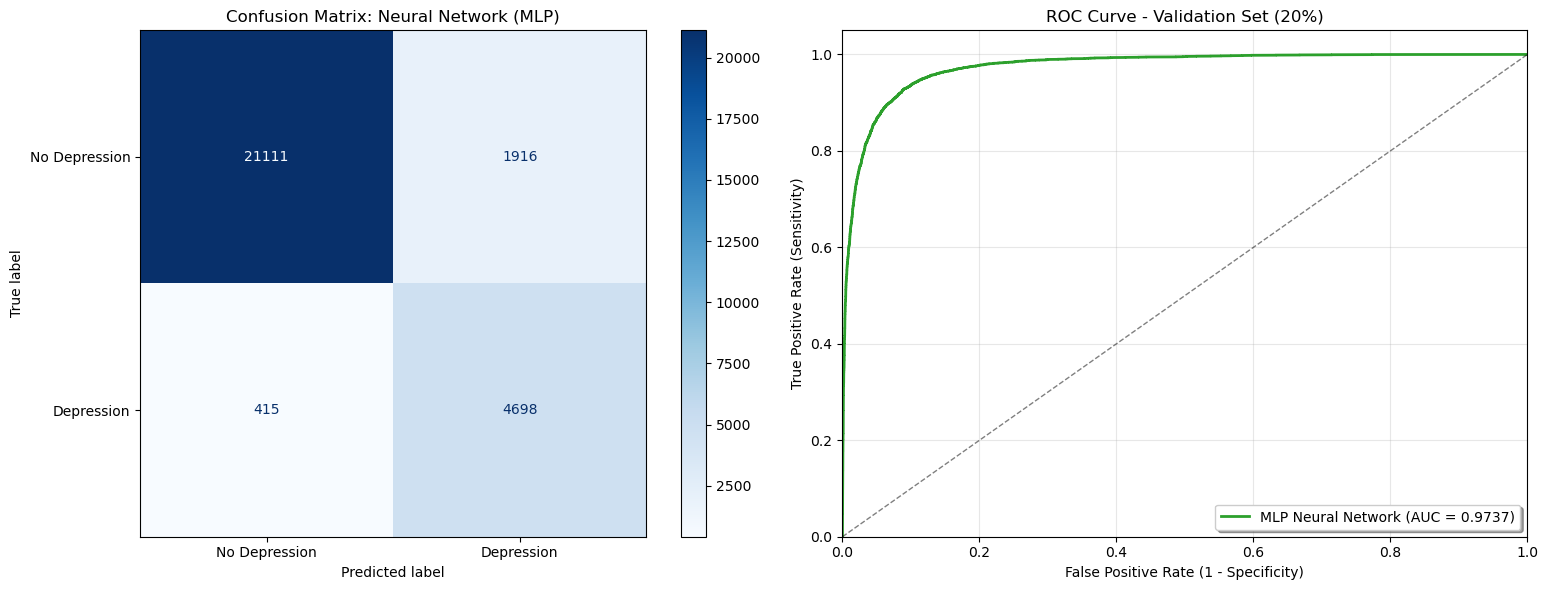

In [11]:
# 1. Tính toán các Metrics cơ bản tại ngưỡng 0.5
val_preds_nn = (val_probs_nn >= 0.5).astype(int)
val_auc_nn = roc_auc_score(y_val, val_probs_nn)
val_f1_nn = f1_score(y_val, val_preds_nn)
val_acc_nn = accuracy_score(y_val, val_preds_nn)

print(f"--- KẾT QUẢ TRÊN TẬP VALIDATION (20%) ---")
print(f"Validation AUC : {val_auc_nn:.4f}")
print(f"Validation F1  : {val_f1_nn:.4f}")
print(f"Validation Acc : {val_acc_nn:.4f}")
print("\n" + "="*50)
print("[Classification Report - Ngưỡng 0.5]")
print(classification_report(y_val, val_preds_nn, target_names=['No Depression', 'Depression']))

# Khởi tạo khung hình
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. Vẽ Confusion Matrix
cm = confusion_matrix(y_val, val_preds_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Depression', 'Depression'])
disp.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title("Confusion Matrix: Neural Network (MLP)")
axes[0].grid(False)

# 3. Vẽ ROC Curve
fpr, tpr, _ = roc_curve(y_val, val_probs_nn)
axes[1].plot(fpr, tpr, color='#2ca02c', lw=2, label=f'MLP Neural Network (AUC = {val_auc_nn:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('ROC Curve - Validation Set (20%)')
axes[1].legend(loc='lower right', frameon=True, shadow=True)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/mlp_diagnostic_analysis.png", dpi=300)
plt.show()

# Lưu dự đoán Validation để tái sử dụng sau này (nếu cần)
np.save(f"{OUTPUT_DIR}/nn_val_probs.npy", val_probs_nn)

**Nhận xét chi tiết và các Insight quan trọng:**
1. Nhận xét về các chỉ số chính (Metrics)
- AUC (0.9737) - "Sát thủ phân loại": Đường cong ROC (hình bên phải) áp sát góc trên bên trái. Điều này chứng tỏ mô hình có khả năng phân biệt cực tốt giữa người bị trầm cảm và người không bị. Xác suất để mô hình xếp hạng một người thực sự trầm cảm cao hơn một người bình thường là hơn 97%.

- Recall lớp Depression (0.92): Đây là con số giá trị nhất trong bài toán này. Nó có nghĩa là: Trong 100 người thực sự bị trầm cảm, mô hình "bắt" được 92 người. Trong y tế, Recall cao giúp hạn chế tối đa việc bỏ sót bệnh nhân (False Negative).

- Precision lớp Depression (0.71): Con số này hơi thấp hơn so với Recall. Có nghĩa là khi mô hình dự đoán "Có trầm cảm", thì thực tế có khoảng 29% là dự đoán nhầm (người bình thường bị gắn nhãn trầm cảm).

2. Phân tích Insight từ Confusion Matrix
- Ô False Negative (415): Đây là số người bị trầm cảm nhưng mô hình đoán là bình thường. Con số này rất nhỏ so với tổng mẫu, cho thấy mô hình của bạn rất "an toàn" cho việc sàng lọc bệnh.
- Ô False Positive (1916): Đây là "điểm yếu" duy nhất. Mô hình đang có xu hướng dự đoán hơi "nhạy quá mức", dẫn đến việc gần 2000 người khỏe mạnh bị chẩn đoán nhầm.

## 12. Tối ưu hóa ngưỡng phân loại (Threshold Optimization)

Mặc định, các mô hình phân loại thường sử dụng ngưỡng **0.5** để quyết định một mẫu thuộc lớp `0` hay `1`. Tuy nhiên, đối với dữ liệu mất cân bằng (Imbalanced Data) và các bài toán y tế, ngưỡng 0.5 thường không mang lại kết quả tốt nhất cho **F1-Score**.

Chúng ta sẽ thực hiện "vét cạn" (Grid Search) các ngưỡng từ **0.1 đến 0.9** trên tập Validation (20%) để tìm ra con số mang lại sự cân bằng hoàn hảo nhất giữa Precision và Recall, từ đó tối đa hóa điểm F1.

--- KẾT QUẢ TỐI ƯU NGƯỠNG ---
Ngưỡng tối ưu (Optimal Threshold): 0.72
F1-Score cao nhất đạt được      : 0.8307


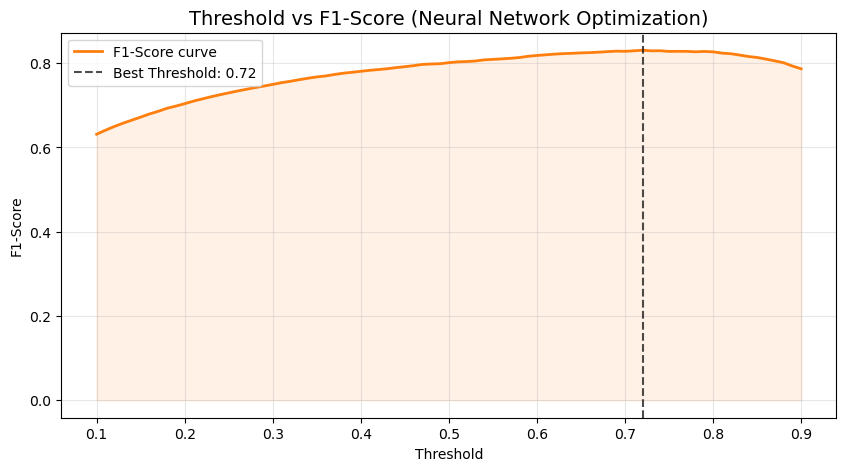

In [12]:
# 1. Định nghĩa dải ngưỡng cần thử nghiệm
thresholds = np.arange(0.1, 0.91, 0.01)
f1_scores = []

# 2. Tính toán F1-Score cho từng ngưỡng trên tập Validation
for t in thresholds:
    v_preds = (val_probs_nn >= t).astype(int)
    f1_scores.append(f1_score(y_val, v_preds))

# 3. Tìm ngưỡng mang lại F1 cao nhất
opt_idx = np.argmax(f1_scores)
opt_threshold = thresholds[opt_idx]
opt_f1 = f1_scores[opt_idx]

print(f"--- KẾT QUẢ TỐI ƯU NGƯỠNG ---")
print(f"Ngưỡng tối ưu (Optimal Threshold): {opt_threshold:.2f}")
print(f"F1-Score cao nhất đạt được      : {opt_f1:.4f}")

# 4. Trực quan hóa quá trình tối ưu
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, color='#ff7f0e', lw=2, label='F1-Score curve')
plt.axvline(opt_threshold, color='black', linestyle='--', alpha=0.7, 
            label=f'Best Threshold: {opt_threshold:.2f}')
plt.fill_between(thresholds, f1_scores, alpha=0.1, color='#ff7f0e')
plt.title('Threshold vs F1-Score (Neural Network Optimization)', fontsize=14)
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Nhận xét:** Việc chuyển từ 0.5 sang 0.72 đã giúp F1-Score của tăng từ 0.8 (ở bước trước) lên 0.8307.

### **Confusion Matrix** tại ngưỡng được tối ưu

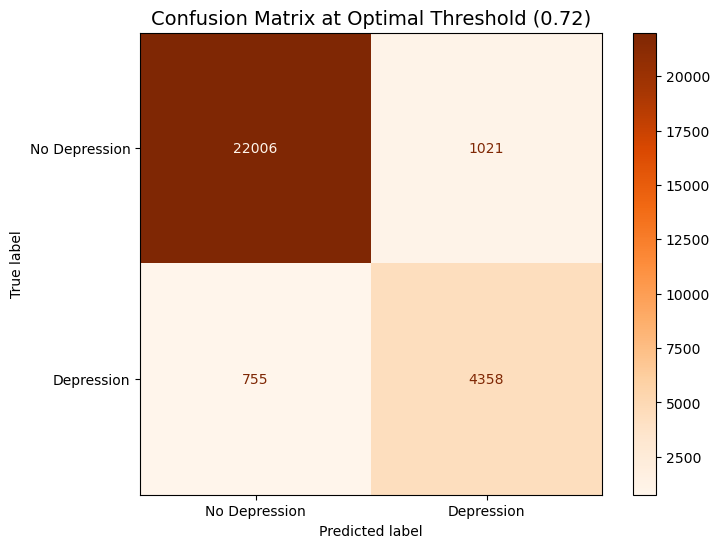

--- ĐÁNH GIÁ TẠI NGƯỠNG TỐI ƯU: 0.72 ---
               precision    recall  f1-score   support

No Depression       0.97      0.96      0.96     23027
   Depression       0.81      0.85      0.83      5113

     accuracy                           0.94     28140
    macro avg       0.89      0.90      0.90     28140
 weighted avg       0.94      0.94      0.94     28140



In [ ]:
val_preds_opt = (val_probs_nn >= opt_threshold).astype(int)

cm_opt = confusion_matrix(y_val, val_preds_opt)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=['No Depression', 'Depression'])
disp.plot(cmap='Oranges', ax=ax, values_format='d')

plt.title(f'Confusion Matrix at Optimal Threshold ({opt_threshold:.2f})', fontsize=14)
plt.grid(False)
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_opt.png", dpi=300)
plt.show()

print(f"--- ĐÁNH GIÁ TẠI NGƯỠNG TỐI ƯU: {opt_threshold:.2f} ---")
print(classification_report(y_val, val_preds_opt, target_names=['No Depression', 'Depression']))

**Nhận xét:**   
So với kết quả ở ngưỡng 0.5 trước đó, ta thấy một sự hoán đổi vị trí rất rõ rệt:
- Precision (0.71 $\rightarrow$ 0.81): Tăng vọt! Bây giờ, khi mô hình dự đoán ai đó bị trầm cảm, khả năng họ thực sự bị bệnh đã lên tới 81%. Chúng ta đã loại bỏ được rất nhiều ca "báo động giả" (False Positives giảm từ 1916 xuống còn 1021).
- Recall (0.92 $\rightarrow$ 0.85): Giảm đi một chút. Điều này là tất yếu. Bằng cách nâng ngưỡng lên cao, mô hình trở nên "khắt khe" hơn, dẫn đến việc bỏ sót thêm một vài ca bệnh thật (False Negatives tăng từ 415 lên 755).

=> Thông qua thực nghiệm tối ưu hóa ngưỡng, nhóm nhận thấy tại ngưỡng 0.72, mô hình MLP đạt được sự cân bằng tối ưu giữa Precision và Recall. Điểm F1-score tăng lên mức 0.83, trong khi độ chính xác tổng thể (Accuracy) đạt 94%. Kết quả này cho thấy mô hình có khả năng sàng lọc trầm cảm với độ tin cậy cao, giảm thiểu đáng kể tỷ lệ báo động giả (False Positive) so với ngưỡng mặc định, trong khi vẫn duy trì được khả năng phát hiện bệnh (Recall) ở mức tốt (85%).


### Tính toán các chỉ số dựa trên ngưỡng tối ưu

In [14]:
val_accuracy_opt = accuracy_score(y_val, val_preds_opt)
val_f1_opt = f1_score(y_val, val_preds_opt)
val_auc_refit = roc_auc_score(y_val, val_probs_nn)

cv_auc_mean = np.mean(cv_auc_scores)
cv_auc_std = np.std(cv_auc_scores)

# Tạo bảng tổng hợp
metrics_summary = {
    'Metric': [
        'CV AUC (Mean)', 
        'CV AUC (Std)', 
        'Validation AUC (Refit)', 
        'Validation F1-Score (Optimal)', 
        'Validation Accuracy (Optimal)',
        'Optimal Threshold'
    ],
    'Value': [
        cv_auc_mean,
        cv_auc_std,
        val_auc_refit,
        val_f1_opt,
        val_accuracy_opt,
        opt_threshold
    ]
}

df_metrics = pd.DataFrame(metrics_summary)

# Lưu xuống file CSV
metrics_file_path = f"{OUTPUT_DIR}/nn_metrics_summary.csv"
df_metrics.to_csv(metrics_file_path, index=False)

print("-" * 30)
print("BẢNG TỔNG HỢP KẾT QUẢ NEURAL NETWORK")
print("-" * 30)
display(df_metrics)
print(f"\nĐã lưu bảng chỉ số tại: {metrics_file_path}")

------------------------------
BẢNG TỔNG HỢP KẾT QUẢ NEURAL NETWORK
------------------------------


,Metric,Value
0,CV AUC (Mean),0.974484
1,CV AUC (Std),0.000549
2,Validation AUC (Refit),0.973741
3,Validation F1-Score (Optimal),0.830728
4,Validation Accuracy (Optimal),0.936887
5,Optimal Threshold,0.720000



Đã lưu bảng chỉ số tại: ../outputs/artifacts/nn_metrics_summary.csv


## 13. Dự đoán tập Test & Xuất file Submission

Bước cuối cùng của Pipeline là áp dụng mô hình MLP đã được huấn luyện tốt nhất lên tập dữ liệu **Test** (`test_nn_ready.pkl`). 

**Quy trình:**
1. Tải tập dữ liệu Test đã qua tiền xử lý (cùng luồng NN).
2. Chuyển đổi sang PyTorch Tensors.
3. Dự đoán xác suất bằng mô hình `final_model`.
4. Quy đổi xác suất sang nhãn nhị phân dựa trên **Ngưỡng tối ưu (opt_threshold)** vừa tìm được.
5. Đóng gói kết quả kèm theo `id` để tạo file nộp bài chuẩn Kaggle.

In [15]:
test_df = pd.read_csv(f"../data/raw/test.csv")
test_ids = test_df['id'].values
# 1. Tải dữ liệu Test dành cho luồng NN
X_test_nn = pd.read_pickle(f"{INPUT_DIR}/test_nn_ready.pkl")

# Loại bỏ cột KFOLD (nếu có)
if 'KFOLD' in X_test_nn.columns:
    X_test_nn = X_test_nn.drop(columns=['KFOLD'])

# 2. Chuyển sang Tensor và đưa lên thiết bị tính toán
X_test_tensor = torch.tensor(X_test_nn.values, dtype=torch.float32).to(device)

# 3. Dự đoán (Inference mode)
final_model.eval()
with torch.no_grad():
    test_logits = final_model(X_test_tensor)
    # Áp dụng Sigmoid để lấy xác suất
    test_probs = torch.sigmoid(test_logits).cpu().numpy().flatten()

# 4. Áp dụng ngưỡng tối ưu để ra nhãn Depression
test_preds = (test_probs >= opt_threshold).astype(int)

# 5. Tạo file Submission
submission_nn = pd.DataFrame({
    'id': test_ids,
    'Depression': test_preds
})

# Lưu file CSV
file_name = f"{OUTPUT_DIR}/submission_neural_network.csv"
submission_nn.to_csv(file_name, index=False)

print(f"KẾT THÚC PIPELINE NEURAL NETWORK.")
print(f"Đã xuất file nộp bài: {file_name}")
display(submission_nn.head())

KẾT THÚC PIPELINE NEURAL NETWORK.
Đã xuất file nộp bài: ../outputs/artifacts/submission_neural_network.csv


,id,Depression
0,140700,0
1,140701,0
2,140702,0
3,140703,1
4,140704,0


## **Tổng hợp đầy đủ các file Output**

Dưới đây là danh sách toàn bộ các tài nguyên được xuất ra từ quá trình huấn luyện và đánh giá Mạng Nơ-ron (MLP). Các file này là nguyên liệu quan trọng cho giai đoạn Stacking, Blending và viết báo cáo.

| Tên file | Mô tả nội dung | Dùng cho phần gì tiếp theo? |
| :--- | :--- | :--- |
| `nn_oof_probs.npy` | Mảng xác suất dự đoán Out-of-Fold (OOF) của mạng Nơ-ron trên tập Train (80%). | **Phần 9: Stacking Ensemble**. Dùng làm Meta-feature đầu vào cho mô hình Meta-learner. |
| `nn_val_probs.npy` | Mảng xác suất dự đoán của mạng Nơ-ron trên tập Validation (20%). | **Phần 10: Blending Ensemble**. Dùng để tính trung bình có trọng số với các mô hình khác (XGB, LGBM, Cat). |
| `nn_metrics_summary.csv` | Bảng tổng hợp chi tiết các chỉ số: CV AUC (Mean/Std), Val AUC, Val F1, Val Acc. | **So sánh hiệu năng**. Dùng để lập bảng đối chiếu kết quả giữa các mô hình trong báo cáo cuối kỳ. |
| `mlp_feature_importance.png` | Biểu đồ tầm quan trọng của các đặc trưng (thường qua Permutation Importance hoặc SHAP). | **Phân tích mô hình**. Giải thích các yếu tố tác động mạnh nhất đến dự đoán trầm cảm của Neural Network. |
| `mlp_diagnostic_analysis.png` | Hình ảnh trực quan hóa gồm Confusion Matrix và ROC Curve trên tập Validation (ngưỡng 0.5). | **Viết Báo Cáo**. Minh chứng trực quan về khả năng phân loại và sai sót của mô hình. |
| `confusion_matrix_opt.png` | Hình ảnh trực quan hóa gồm Confusion Matrix ở ngưỡng tối ưu. | **Viết Báo Cáo**. Minh chứng trực quan về khả năng phân loại và sai sót của mô hình. |
| `best_mlp_final.pt` | File lưu trữ trọng số (weights) tốt nhất của mô hình sau khi huấn luyện trên toàn bộ tập Train. | **Dự đoán Test Set**. Load lại để sinh dự đoán cuối cùng cho tập Test của Kaggle. |
| `best_mlp_checkpoint.pt` | File checkpoint được lưu bởi Early Stopping khi mô hình đạt Val Loss thấp nhất. | **Backup & Refit**. Đảm bảo có thể khôi phục lại trạng thái tốt nhất của mô hình nếu quá trình Refit bị lỗi. |
| `mlp_fold_x.pt` <br>*(x: 1->5)* | Các file checkpoint trọng số của từng nếp gấp (Fold) trong quá trình 5-Fold CV. | **Kiểm tra độ ổn định**. Chứng minh sự nhất quán của kiến trúc MLP trên các nếp gấp dữ liệu khác nhau. |
| `submission_neural_network.csv`| File kết quả theo đúng format quy định (2 cột: `id` và `Depression`) sau khi đã áp dụng ngưỡng tối ưu (Optimal Threshold). | **Nộp bài Kaggle**. Lấy điểm Leaderboard riêng cho mô hình Neural Network. |